In [1]:
# =============================================================================
# SUPPLY CHAIN OPTIMIZATION — DataCo Global
# Notebook 02: Delivery Risk Prediction
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

DATA_PATH = Path('../data/processed')
IMG_PATH  = Path('../img')

PALETTE = {
    'primary'  : '#1A6FBF',
    'secondary': '#E8622A',
    'accent'   : '#5B4FCF',
    'success'  : '#2A9D5C',
    'warning'  : '#E8A020',
    'neutral'  : '#4A5568',
    'light'    : '#F7F9FC',
    'border'   : '#E2E8F0',
    'text'     : '#1A202C',
    'muted'    : '#718096',
}

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : PALETTE['light'],
    'axes.edgecolor'   : PALETTE['border'],
    'axes.labelcolor'  : PALETTE['text'],
    'axes.titlecolor'  : PALETTE['text'],
    'xtick.color'      : PALETTE['neutral'],
    'ytick.color'      : PALETTE['neutral'],
    'text.color'       : PALETTE['text'],
    'grid.color'       : PALETTE['border'],
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.titleweight' : 'bold',
})

print("✅ Imports and config ready")

✅ Imports and config ready


In [2]:
# ── 1. LOAD DATA & FEATURE ENGINEERING ───────────────────────────────────────
df = pd.read_csv(DATA_PATH / 'supply_chain_clean.csv')

# Features available BEFORE shipment (no data leakage)
features = [
    'Days for shipment (scheduled)',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Sales',
    'Order Item Total',
    'Shipping Mode',
    'Market',
    'Customer Segment',
    'Department Name',
    'order_month',
    'order_quarter',
    'Type',                    # payment type
]

target = 'is_late'

# Encode categoricals
df_model = df[features + [target]].copy()
cat_cols  = ['Shipping Mode', 'Market', 'Customer Segment',
             'Department Name', 'Type']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model.dropna(inplace=True)

X = df_model[features]
y = df_model[target]

# Train/test split — time-aware (last 20% as test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Features ready")
print(f"   Train: {X_train.shape[0]:,} rows")
print(f"   Test:  {X_test.shape[0]:,} rows")
print(f"   Features: {X_train.shape[1]}")
print(f"   Target balance — Late: {y.mean():.1%} | On-time: {1-y.mean():.1%}")
print(f"\nFeatures used:")
for f in features:
    print(f"   · {f}")

✅ Features ready
   Train: 144,408 rows
   Test:  36,103 rows
   Features: 14
   Target balance — Late: 54.8% | On-time: 45.2%

Features used:
   · Days for shipment (scheduled)
   · Order Item Quantity
   · Order Item Discount Rate
   · Order Item Product Price
   · Order Item Profit Ratio
   · Sales
   · Order Item Total
   · Shipping Mode
   · Market
   · Customer Segment
   · Department Name
   · order_month
   · order_quarter
   · Type


In [4]:
# ── 2. TRAIN MODELS ───────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Logistic Regression — baseline
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred  = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

# XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, eval_metric='logloss',
                     verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)

print("Model Performance Summary")
print("=" * 50)
print(f"{'Model':<25} {'AUC-ROC':>10}")
print("-" * 50)
print(f"{'Logistic Regression':<25} {lr_auc:>10.4f}")
print(f"{'Random Forest':<25} {rf_auc:>10.4f}")
print(f"{'XGBoost':<25} {xgb_auc:>10.4f}")
print("=" * 50)
print(f"\nBest model: XGBoost" if xgb_auc >= rf_auc else f"\nBest model: Random Forest")

Model Performance Summary
Model                        AUC-ROC
--------------------------------------------------
Logistic Regression           0.7267
Random Forest                 0.7427
XGBoost                       0.7397

Best model: Random Forest


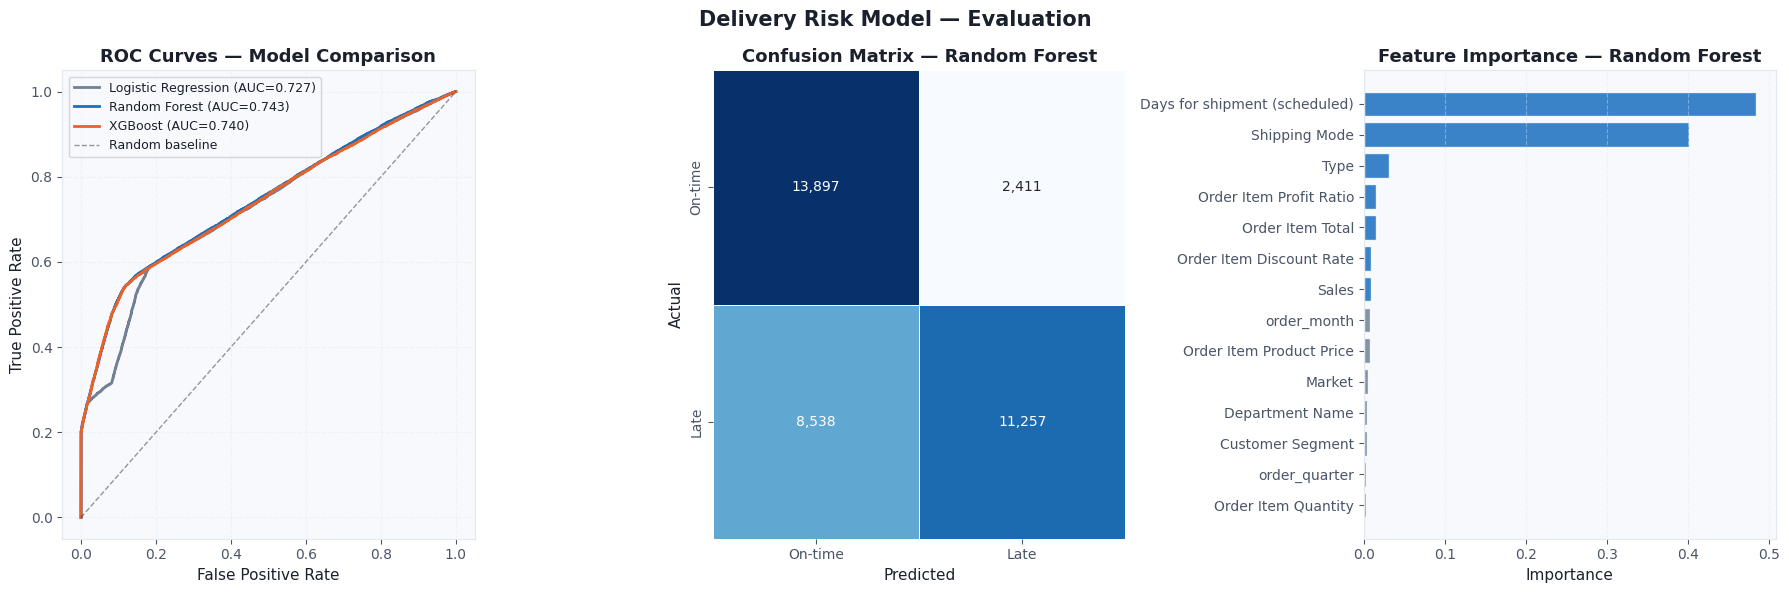

✅ Saved: model_evaluation.png

Classification Report — Random Forest:
              precision    recall  f1-score   support

     On-time       0.62      0.85      0.72     16308
        Late       0.82      0.57      0.67     19795

    accuracy                           0.70     36103
   macro avg       0.72      0.71      0.70     36103
weighted avg       0.73      0.70      0.69     36103



In [6]:
# ── 3. MODEL EVALUATION VISUALIZATION ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Delivery Risk Model — Evaluation', fontsize=15,
             fontweight='bold', color=PALETTE['text'])

# ROC Curves
ax = axes[0]
for name, proba, auc, color in [
    ('Logistic Regression', lr_proba,  lr_auc,  PALETTE['muted']),
    ('Random Forest',       rf_proba,  rf_auc,  PALETTE['primary']),
    ('XGBoost',             xgb_proba, xgb_auc, PALETTE['secondary']),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
            color=color, linewidth=2)

ax.plot([0,1], [0,1], 'k--', alpha=0.4, linewidth=1, label='Random baseline')
ax.set_title('ROC Curves — Model Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# Confusion Matrix — Random Forest (best model)
ax = axes[1]
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['On-time', 'Late'],
            yticklabels=['On-time', 'Late'],
            cbar=False, linewidths=0.5)
ax.set_title('Confusion Matrix — Random Forest')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# Feature importance — Random Forest
ax = axes[2]
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
colors_fi = [PALETTE['primary'] if v > feat_imp.median() else PALETTE['muted']
             for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors_fi,
        alpha=0.85, edgecolor='white')
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig(IMG_PATH / 'model_evaluation.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: model_evaluation.png")
print(f"\nClassification Report — Random Forest:")
print(classification_report(y_test, rf_pred, target_names=['On-time', 'Late']))

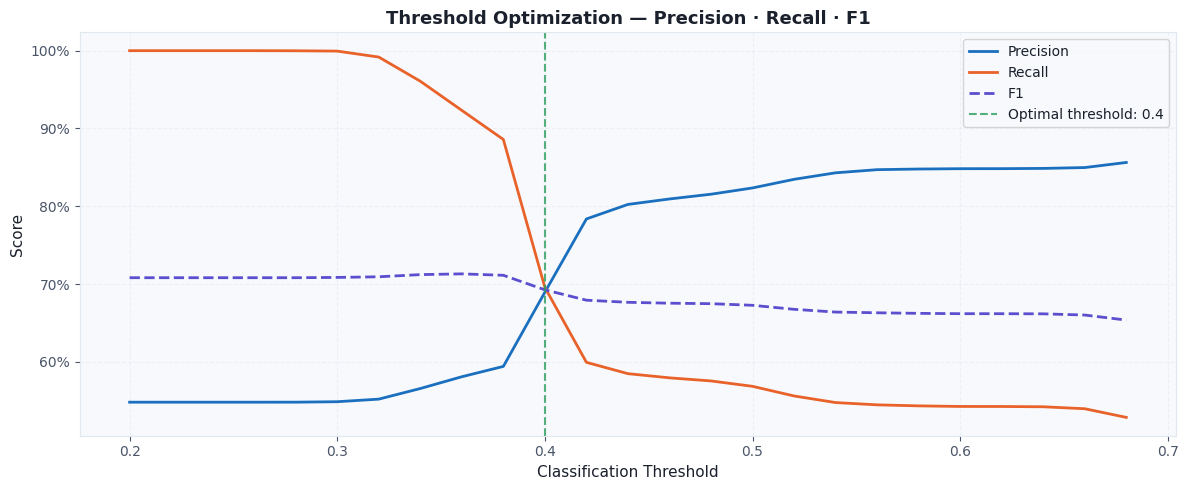

✅ Optimal threshold: 0.4
   Precision: 68.96%
   Recall:    69.57%
   F1:        69.27%
   TP: 13,772  FP: 6,198
   TN: 10,110  FN: 6,023


In [7]:
# ── 4. THRESHOLD OPTIMIZATION ─────────────────────────────────────────────────
thresholds  = np.arange(0.20, 0.70, 0.02)
results     = []

for thresh in thresholds:
    preds    = (rf_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    results.append({
        'threshold' : round(thresh, 2),
        'precision' : precision,
        'recall'    : recall,
        'f1'        : f1,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
    })

thresh_df = pd.DataFrame(results)

# Best threshold — maximize recall with precision > 0.65
candidates = thresh_df[thresh_df['precision'] >= 0.65]
best_thresh = candidates.loc[candidates['recall'].idxmax(), 'threshold']
best_row    = thresh_df[thresh_df['threshold'] == best_thresh].iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor(PALETTE['light'])

ax.plot(thresh_df['threshold'], thresh_df['precision'],
        color=PALETTE['primary'], linewidth=2, label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'],
        color=PALETTE['secondary'], linewidth=2, label='Recall')
ax.plot(thresh_df['threshold'], thresh_df['f1'],
        color=PALETTE['accent'], linewidth=2, linestyle='--', label='F1')
ax.axvline(best_thresh, color=PALETTE['success'], linewidth=1.5,
           linestyle='--', alpha=0.8, label=f'Optimal threshold: {best_thresh}')
ax.set_title('Threshold Optimization — Precision · Recall · F1',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.savefig(IMG_PATH / 'threshold_optimization.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

print(f"✅ Optimal threshold: {best_thresh}")
print(f"   Precision: {best_row['precision']:.2%}")
print(f"   Recall:    {best_row['recall']:.2%}")
print(f"   F1:        {best_row['f1']:.2%}")
print(f"   TP: {int(best_row['tp']):,}  FP: {int(best_row['fp']):,}")
print(f"   TN: {int(best_row['tn']):,}  FN: {int(best_row['fn']):,}")

In [8]:
# ── 5. BUSINESS IMPACT ────────────────────────────────────────────────────────
# Conservative cost assumptions
cost_late_undetected  = 25   # $ per undetected late delivery (penalties + churn risk)
cost_false_alert      = 3    # $ per false positive (unnecessary intervention cost)
savings_per_detection = 15   # $ saved per correctly flagged late delivery

tp = int(best_row['tp'])  # correctly flagged late
fp = int(best_row['fp'])  # false alerts
fn = int(best_row['fn'])  # missed late deliveries

# Annual scale (dataset spans ~3 years)
annual_factor = 12 / 36

tp_annual = int(tp * annual_factor * 12)
fp_annual = int(fp * annual_factor * 12)
fn_annual = int(fn * annual_factor * 12)

# Without model — all late deliveries undetected
baseline_cost = int(df['is_late'].sum() * annual_factor * 12) * cost_late_undetected

# With model
model_savings   = tp_annual * savings_per_detection
model_fp_cost   = fp_annual * cost_false_alert
model_fn_cost   = fn_annual * cost_late_undetected
model_net       = model_savings - model_fp_cost - model_fn_cost
net_benefit     = baseline_cost - (model_fp_cost + model_fn_cost)

print("=" * 60)
print("BUSINESS IMPACT — Delivery Risk Model")
print("=" * 60)
print(f"\nCost assumptions (conservative):")
print(f"   Cost per undetected late delivery: ${cost_late_undetected}")
print(f"   Cost per false alert:              ${cost_false_alert}")
print(f"   Savings per detected late:         ${savings_per_detection}")
print(f"\nAnnual projections (test set × annual scale):")
print(f"   Late deliveries detected (TP):  {tp_annual:>8,}")
print(f"   False alerts (FP):              {fp_annual:>8,}")
print(f"   Missed late deliveries (FN):    {fn_annual:>8,}")
print(f"\nWithout model:")
print(f"   Annual cost of late deliveries: ${baseline_cost:>10,}")
print(f"\nWith model:")
print(f"   Savings from detections:        ${model_savings:>10,}")
print(f"   Cost of false alerts:           ${model_fp_cost:>10,}")
print(f"   Cost of missed deliveries:      ${model_fn_cost:>10,}")
print(f"   Net benefit vs no model:        ${net_benefit:>10,}")
print("=" * 60)
print(f"\n💡 The model identifies ${model_savings:,} in annual savings")
print(f"   by flagging {tp_annual:,} at-risk deliveries for intervention")
print(f"   at a net benefit of ${net_benefit:,} per year")

BUSINESS IMPACT — Delivery Risk Model

Cost assumptions (conservative):
   Cost per undetected late delivery: $25
   Cost per false alert:              $3
   Savings per detected late:         $15

Annual projections (test set × annual scale):
   Late deliveries detected (TP):    55,087
   False alerts (FP):                24,792
   Missed late deliveries (FN):      24,092

Without model:
   Annual cost of late deliveries: $ 9,897,300

With model:
   Savings from detections:        $   826,305
   Cost of false alerts:           $    74,376
   Cost of missed deliveries:      $   602,300
   Net benefit vs no model:        $ 9,220,624

💡 The model identifies $826,305 in annual savings
   by flagging 55,087 at-risk deliveries for intervention
   at a net benefit of $9,220,624 per year


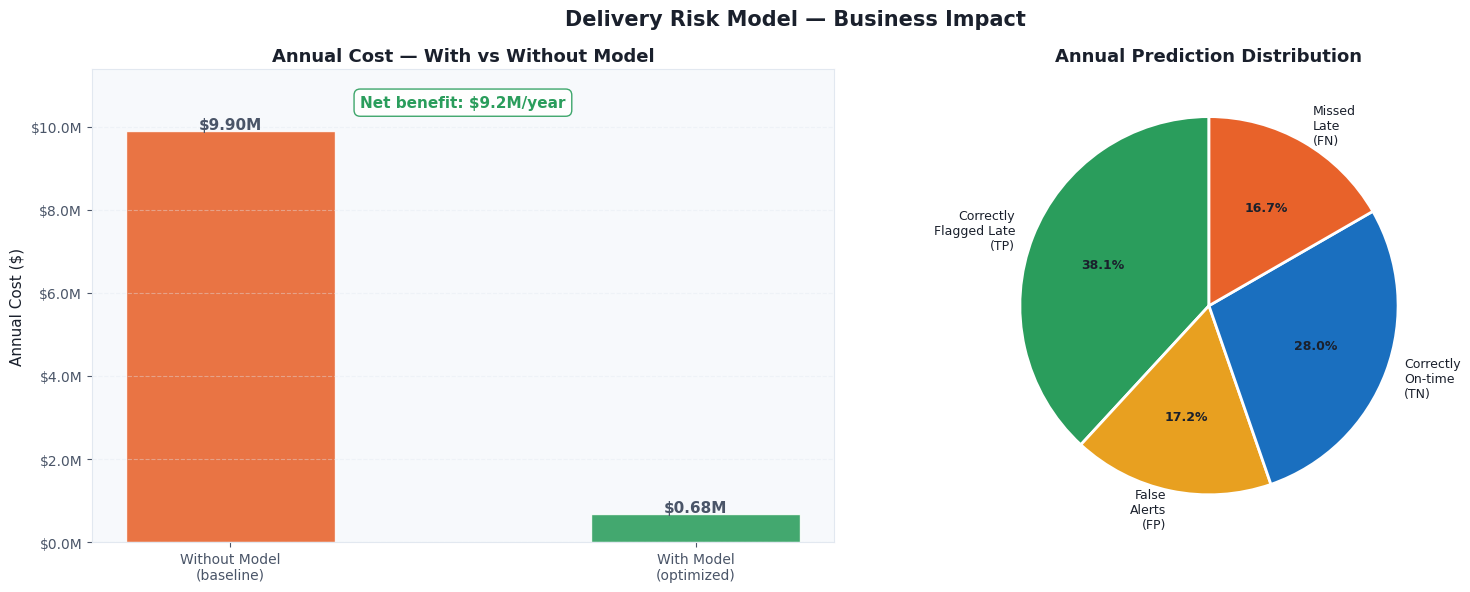

✅ Saved: business_impact_model.png


In [9]:
# ── 6. BUSINESS IMPACT VISUALIZATION ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Delivery Risk Model — Business Impact',
             fontsize=15, fontweight='bold', color=PALETTE['text'])

# Cost comparison: with vs without model
ax = axes[0]
categories = ['Without Model\n(baseline)', 'With Model\n(optimized)']
costs      = [baseline_cost, model_fp_cost + model_fn_cost]
colors_bar = [PALETTE['secondary'], PALETTE['success']]
bars = ax.bar(categories, costs, color=colors_bar,
              alpha=0.88, edgecolor='white', width=0.45)
ax.set_title('Annual Cost — With vs Without Model')
ax.set_ylabel('Annual Cost ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'${val/1e6:.2f}M', ha='center', fontsize=11,
            fontweight='bold', color=PALETTE['neutral'])
ax.text(0.5, 0.92, f'Net benefit: ${net_benefit/1e6:.1f}M/year',
        transform=ax.transAxes, ha='center', fontsize=11,
        fontweight='bold', color=PALETTE['success'],
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=PALETTE['success'], alpha=0.9))
ax.set_ylim(0, baseline_cost * 1.15)
ax.grid(True, alpha=0.4, axis='y')

# Prediction breakdown
ax = axes[1]
labels = ['Correctly\nFlagged Late\n(TP)', 'False\nAlerts\n(FP)',
          'Correctly\nOn-time\n(TN)', 'Missed\nLate\n(FN)']
values = [tp_annual, fp_annual, int(best_row['tn'] * annual_factor * 12), fn_annual]
colors_pie = [PALETTE['success'], PALETTE['warning'],
              PALETTE['primary'], PALETTE['secondary']]
wedges, texts, autotexts = ax.pie(
    values, labels=labels, colors=colors_pie,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=9)
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Annual Prediction Distribution')

plt.tight_layout()
plt.savefig(IMG_PATH / 'business_impact_model.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: business_impact_model.png")

In [10]:
# ── 7. SAVE RESULTS ───────────────────────────────────────────────────────────
import os
os.makedirs('../data/processed', exist_ok=True)

# Save predictions on test set
test_results = X_test.copy()
test_results['actual']          = y_test.values
test_results['predicted_proba'] = rf_proba
test_results['predicted_label'] = (rf_proba >= best_thresh).astype(int)
test_results.to_csv('../data/processed/delivery_risk_predictions.csv', index=False)

# Save model metrics
metrics = pd.DataFrame([{
    'model'          : 'Random Forest',
    'auc_roc'        : round(rf_auc, 4),
    'threshold'      : best_thresh,
    'precision'      : round(best_row['precision'], 4),
    'recall'         : round(best_row['recall'], 4),
    'f1'             : round(best_row['f1'], 4),
    'tp_annual'      : tp_annual,
    'fp_annual'      : fp_annual,
    'fn_annual'      : fn_annual,
    'annual_savings' : model_savings,
    'net_benefit'    : net_benefit,
}])
metrics.to_csv('../data/processed/delivery_risk_metrics.csv', index=False)

print("✅ Results saved")
print(f"   delivery_risk_predictions → {len(test_results):,} rows")
print(f"   delivery_risk_metrics     → model performance summary")
print(f"\nFinal model summary:")
print(f"   Model:          Random Forest")
print(f"   AUC-ROC:        {rf_auc:.4f}")
print(f"   Threshold:      {best_thresh}")
print(f"   Recall (Late):  {best_row['recall']:.2%}")
print(f"   Annual savings: ${model_savings:,}")
print(f"   Net benefit:    ${net_benefit:,}")

✅ Results saved
   delivery_risk_predictions → 36,103 rows
   delivery_risk_metrics     → model performance summary

Final model summary:
   Model:          Random Forest
   AUC-ROC:        0.7427
   Threshold:      0.4
   Recall (Late):  69.57%
   Annual savings: $826,305
   Net benefit:    $9,220,624
